In [ ]:
# %pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
train = pd.read_csv("train.csv", parse_dates=["date"])
test = pd.read_csv("test.csv", parse_dates=["date"])
sample_submission = pd.read_csv("sample_submission.csv")

In [ ]:
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
test.head()

,id,date,store,item
0,0,01-01-2018,1,1
1,1,02-01-2018,1,1
2,2,03-01-2018,1,1
3,3,04-01-2018,1,1
4,4,05-01-2018,1,1


In [ ]:
sample_submission.head()

,id,sales
0,0,52
1,1,52
2,2,52
3,3,52
4,4,52


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


In [ ]:
train.shape, test.shape, sample_submission.shape

((913000, 4), (45000, 4), (45000, 2))

In [ ]:
train.dtypes

date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object

In [ ]:
train.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [ ]:
test.isnull().sum()

id       0
date     0
store    0
item     0
dtype: int64

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


In [ ]:
train.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


In [ ]:
train['date'].min(), train['date'].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2017-12-31 00:00:00'))

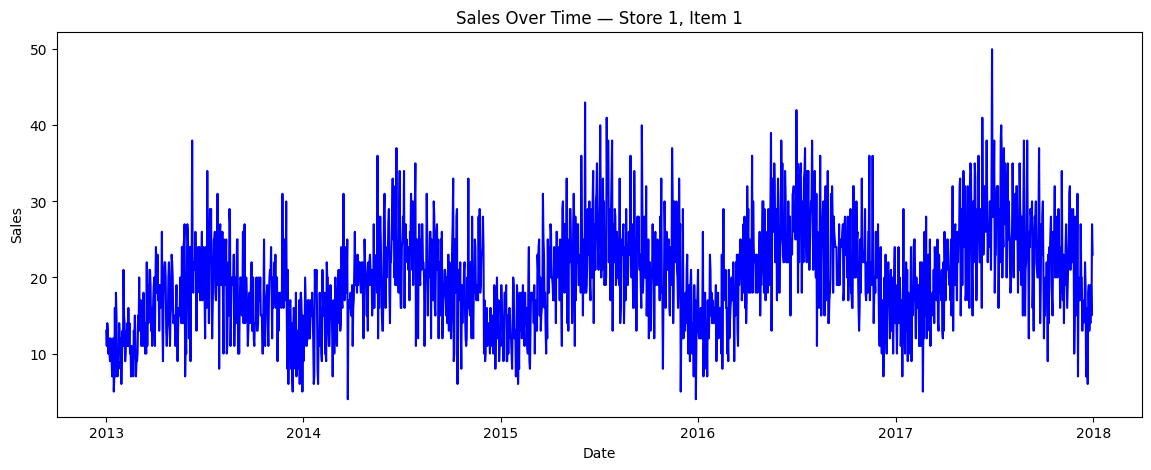

In [ ]:
sample = train[(train['store']==1) & (train['item']==1)]

plt.figure(figsize=(14,5))
plt.plot(sample['date'], sample['sales'], color='blue')
plt.title("Sales Over Time — Store 1, Item 1")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [ ]:
# This is one time series out of 500 (10 stores × 50 items)

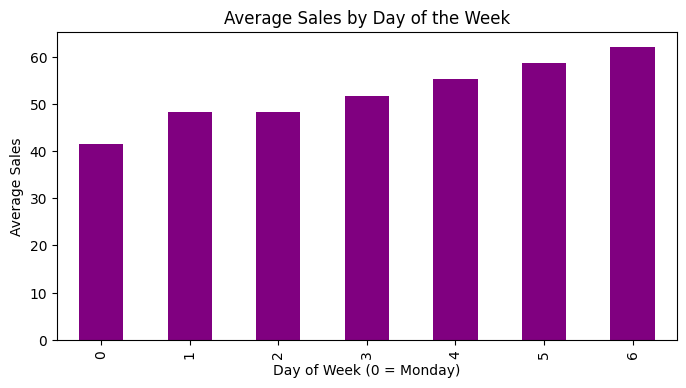

In [ ]:
train['dayofweek'] = train['date'].dt.dayofweek
grouped = train.groupby('dayofweek')['sales'].mean()

plt.figure(figsize=(8,4))
grouped.plot(kind='bar', color='purple')
plt.title("Average Sales by Day of the Week")
plt.xlabel("Day of Week (0 = Monday)")
plt.ylabel("Average Sales")
plt.show()


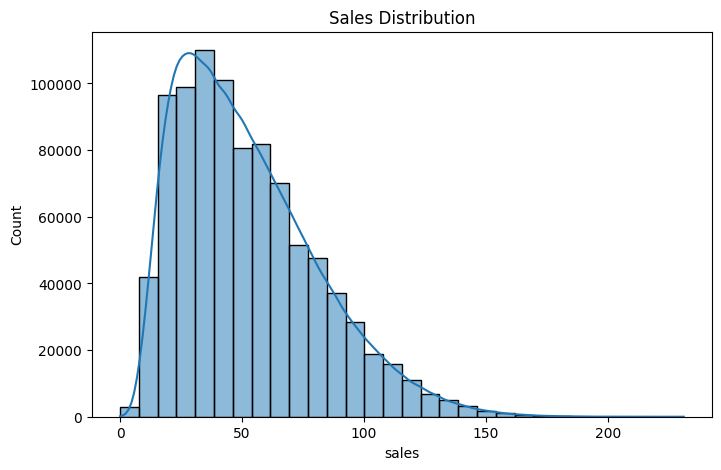

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(train['sales'], bins=30, kde=True)
plt.title("Sales Distribution")
plt.show()

In [ ]:
train['store'].nunique(), train['item'].nunique()

(10, 50)

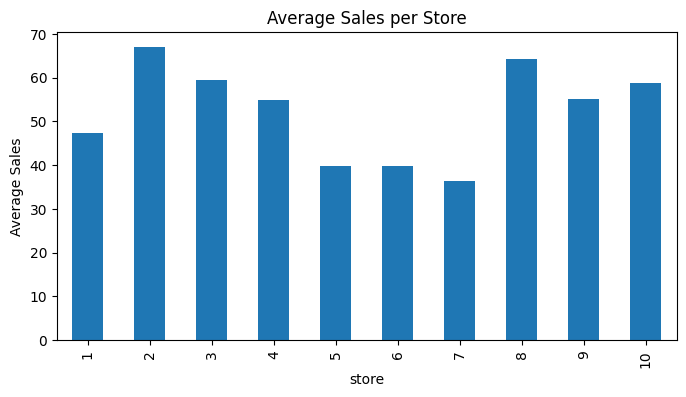

In [ ]:
store_sales = train.groupby('store')['sales'].mean()

plt.figure(figsize=(8,4))
store_sales.plot(kind='bar')
plt.title("Average Sales per Store")
plt.ylabel("Average Sales")
plt.show()

Text(0.5, 1.0, 'Average Sales')

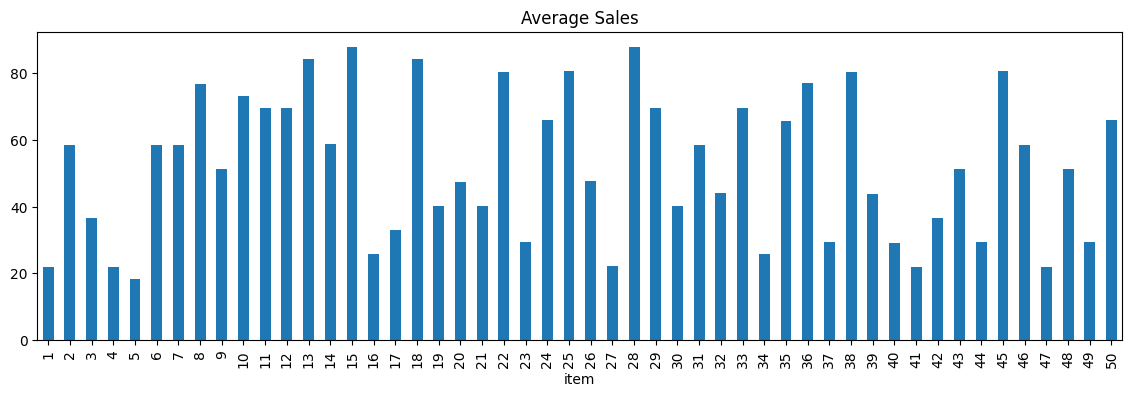

In [ ]:
item_sales = train.groupby('item')['sales'].mean()

plt.figure(figsize=(14,4))
item_sales.plot(kind='bar')
plt.title("Average Sales")

In [ ]:
sample = train[(train['store']==1) & (train['item']==1)].set_index('date')

# Generate full date range
full_range = pd.date_range(start=sample.index.min(), end=sample.index.max())

missing = full_range.difference(sample.index)

missing

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

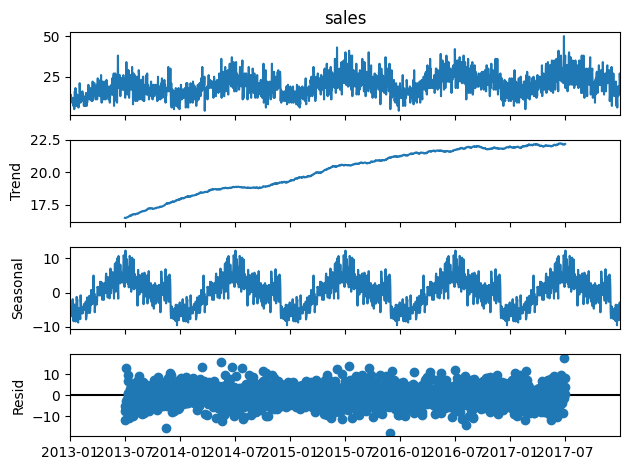

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(sample['sales'], model='additive', period=365)
result.plot()
plt.show()

In [ ]:
train[['store','item','sales']].corr()

,store,item,sales
store,1.000000e+00,7.276042e-15,-0.008170
item,7.276042e-15,1.000000e+00,-0.055998
sales,-8.170361e-03,-5.599807e-02,1.000000


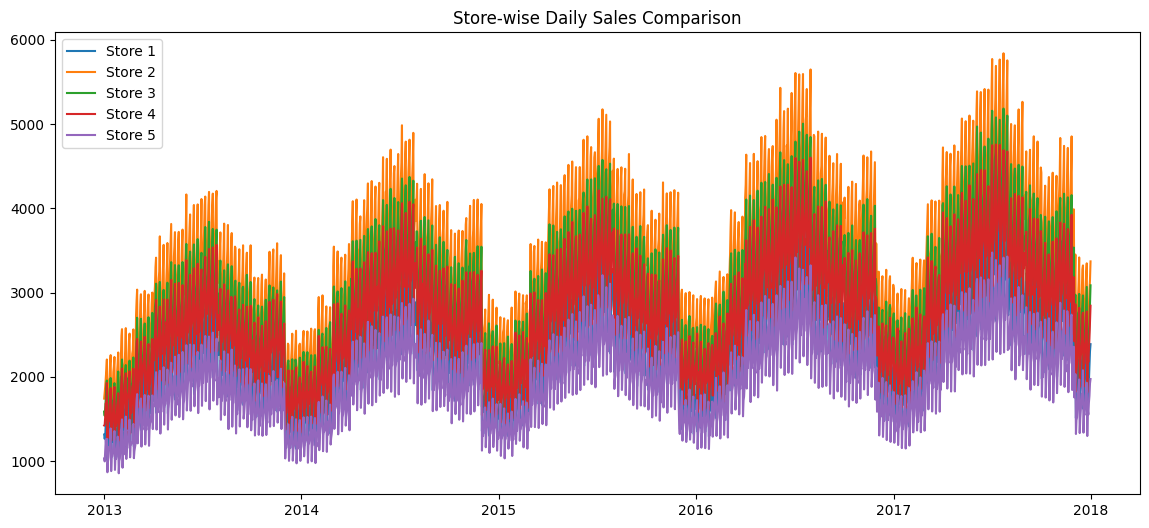

In [ ]:
plt.figure(figsize=(14,6))
for s in range(1, 6):  # first 5 stores
    subset = train[train['store']==s].groupby('date')['sales'].sum()
    plt.plot(subset, label=f"Store {s}")

plt.legend()
plt.title("Store-wise Daily Sales Comparison")
plt.show()

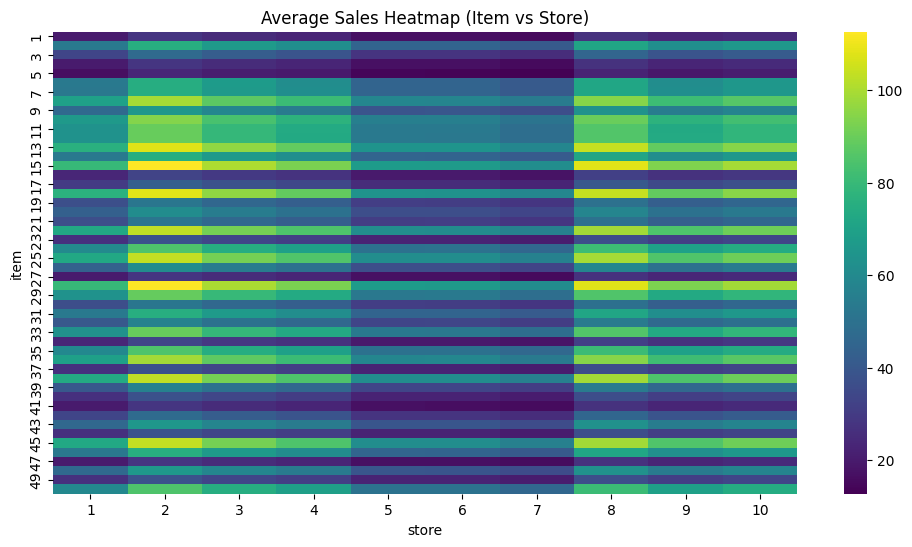

In [ ]:
item_pivot = train.pivot_table(index='item', columns='store', values='sales', aggfunc='mean')
plt.figure(figsize=(12,6))
sns.heatmap(item_pivot, cmap='viridis')
plt.title("Average Sales Heatmap (Item vs Store)")
plt.show()


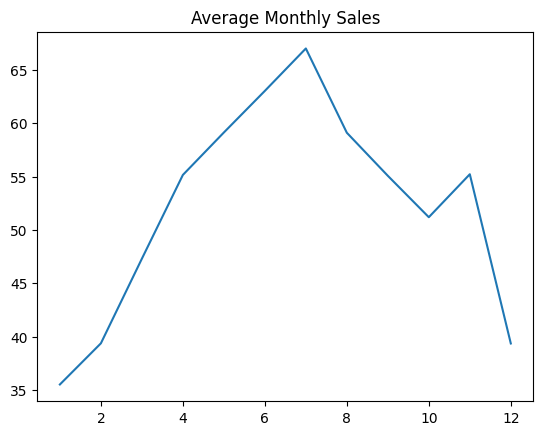

In [ ]:
train['month'] = train['date'].dt.month
monthly = train.groupby('month')['sales'].mean()

plt.plot(monthly)
plt.title("Average Monthly Sales")
plt.show()


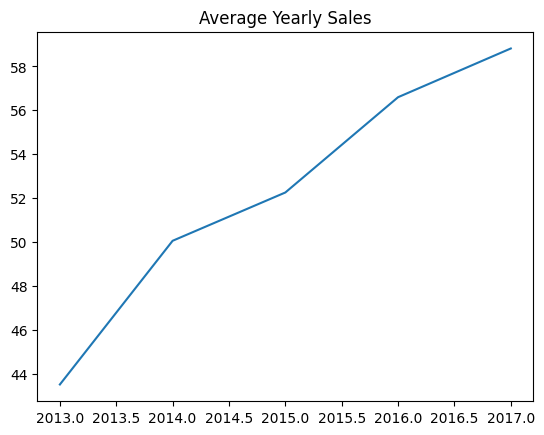

In [ ]:
train['year'] = train['date'].dt.year
yearly = train.groupby('year')['sales'].mean()

plt.plot(yearly)
plt.title("Average Yearly Sales")
plt.show()


<Axes: xlabel='sales'>

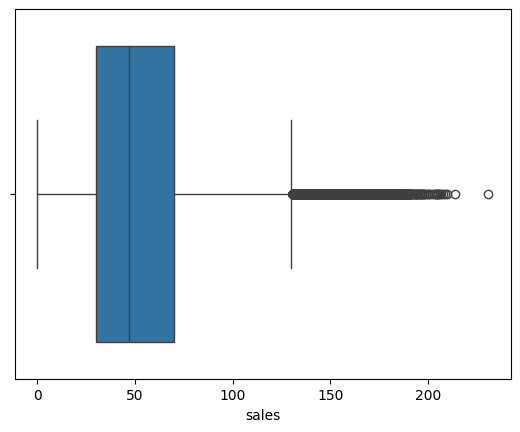

In [ ]:
sns.boxplot(x=train['sales'])

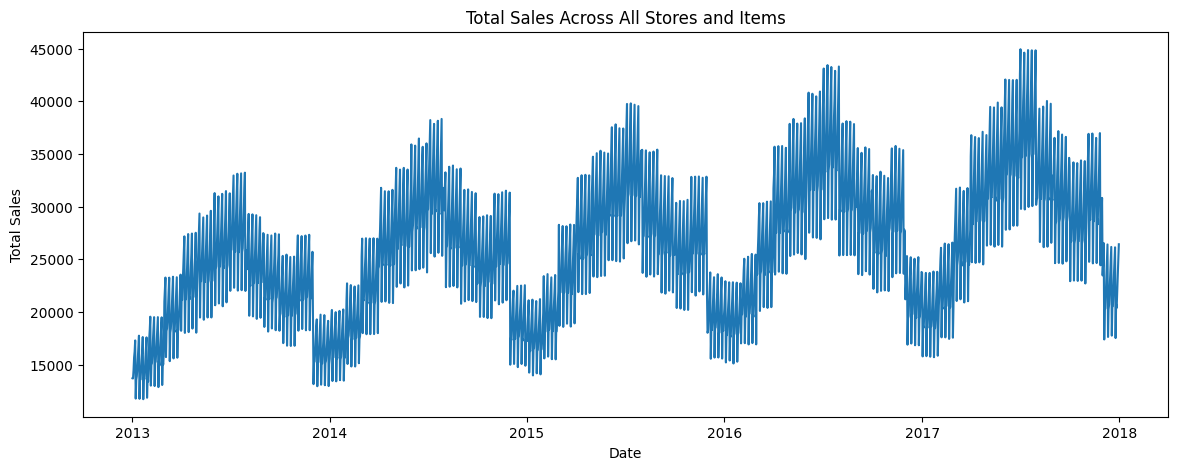

In [ ]:
daily_sales = train.groupby('date')['sales'].sum()

plt.figure(figsize=(14,5))
plt.plot(daily_sales)
plt.title("Total Sales Across All Stores and Items")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(sample['sales'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -3.157670556332791
p-value: 0.022569380626572377


In [ ]:
# “A stationary time series has constant mean, variance, and autocorrelation over time.”
# Perform an Augmented Dickey-Fuller (ADF) test
# p-value < 0.05 → stationary
# p-value ≥ 0.05 → non-stationary (more common)
# Stationarity helps classical models (ARIMA)
# Machine learning models like XGBoost do not need stationary series, but it's good to know

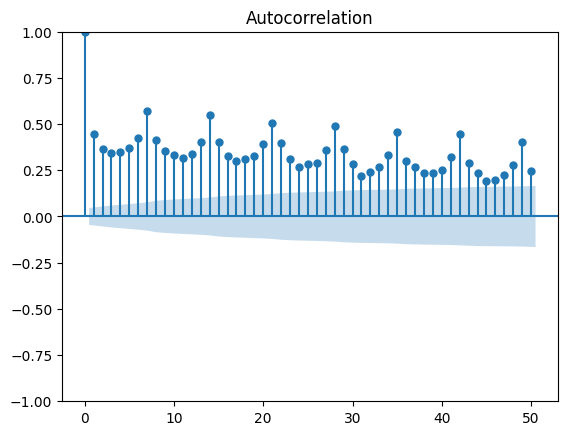

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(sample['sales'], lags=50)
plt.show()

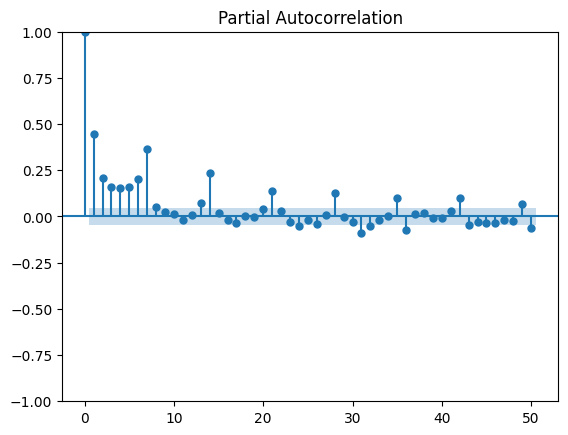

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(sample['sales'], lags=50)
plt.show()

In [ ]:
# Peaks at lags show repeated patterns
# Strong weekly seasonality often appears at lag 7


In [ ]:
df = train.copy()

In [ ]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['week'] = df['date'].dt.isocalendar().week
df['dayofweek'] = df['date'].dt.dayofweek

In [ ]:
df = df.sort_values(['store','item','date'])

df['lag_1'] = df.groupby(['store','item'])['sales'].shift(1)     # yesterday
df['lag_7'] = df.groupby(['store','item'])['sales'].shift(7)     # last week
df['lag_30'] = df.groupby(['store','item'])['sales'].shift(30)   # last month


In [ ]:
# Rolling windows capture trends over time.
# average of past 7 days and 30 days respectively

df['rolling_7'] = (
    df.groupby(['store','item'])['sales']
      .shift(1)
      .rolling(7)
      .mean()
)

df['rolling_30'] = (
    df.groupby(['store','item'])['sales']
      .shift(1)
      .rolling(30)
      .mean()
)

In [ ]:
df = df.dropna()

In [ ]:
# # “Never use future information to predict the future.”
# Bad Examples related leakage:
# Using today's sales to predict today's sales
# Rolling mean without .shift(1)
# Using test data to create features

# Correct approach:
# ✔ Always shift features
# ✔ Create lags only with past data
# ✔ Keep train/validation split by date


In [ ]:
features = [
    'store', 'item',
    'year','month','day','week','dayofweek',
    'lag_1','lag_7','lag_30',
    'rolling_7','rolling_30'
]

target = 'sales'

In [ ]:
train_df = df[df['date'] < "2017-01-01"]
valid_df = df[df['date'] >= "2017-01-01"]

X_train = train_df[features]
y_train = train_df[target]

X_valid = valid_df[features]
y_valid = valid_df[target]

In [ ]:
X_train

,store,item,year,month,day,week,dayofweek,lag_1,lag_7,lag_30,rolling_7,rolling_30
30,1,1,2013,1,31,5,3,9.0,8.0,13.0,10.285714,10.500000
31,1,1,2013,2,1,5,4,13.0,14.0,11.0,11.000000,10.500000
32,1,1,2013,2,2,5,5,11.0,12.0,14.0,10.571429,10.500000
33,1,1,2013,2,3,5,6,21.0,12.0,13.0,11.857143,10.733333
34,1,1,2013,2,4,6,0,15.0,11.0,10.0,12.285714,10.800000
...,...,...,...,...,...,...,...,...,...,...,...,...
912630,10,50,2016,12,27,52,1,61.0,58.0,106.0,61.714286,65.400000
912631,10,50,2016,12,28,52,2,60.0,64.0,74.0,62.000000,63.866667
912632,10,50,2016,12,29,52,3,43.0,56.0,84.0,59.000000,62.833333
912633,10,50,2016,12,30,52,4,68.0,64.0,74.0,60.714286,62.300000


In [ ]:
y_train

30        13
31        11
32        21
33        15
34        14
          ..
912630    60
912631    43
912632    68
912633    63
912634    64
Name: sales, Length: 715500, dtype: int64

In [ ]:
# Our dataset covers:
# 2013 to 2017 (train data)
# 2018 (to be predicted in test.csv)

# A natural split:
# Training period: 2013‑01‑01 → 2016‑12‑31
# Validation period: 2017‑01‑01 → 2017‑12‑31

# Why use 2017 as validation?
# Because:
# It is the most recent year before the test period (2018)
# The model learns from older years and must forecast a full year (2017)
# This mimics real‑world forecasting for 2018

In [ ]:
# X_train → all input features
# y_train → the value we want to predict
# X_valid → features for validation period
# y_valid → true sales for 2017

# Later, the model will:
# Learn from X_train → predict y_train
# Predict X_valid → compare with y_valid

# This gives us evaluation accuracy.

In [ ]:
print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)

(715500, 12) (715500,)
(182500, 12) (182500,)


In [ ]:
# Training set should be much larger (4 years)
# Validation set is smaller (1 year)

# If validation is too small:
# evaluation will be unstable
#  model may underfit patterns

# If validation uses mixed dates:
#  leakage will happen
#  false high accuracy

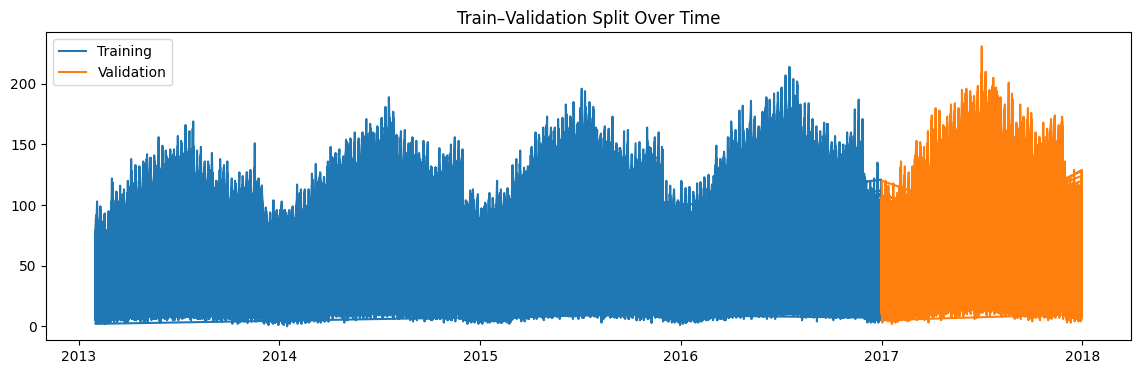

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(train_df['date'], y_train, label='Training')
plt.plot(valid_df['date'], y_valid, label='Validation')
plt.legend()
plt.title("Train–Validation Split Over Time")
plt.show()

In [ ]:
# Blue line = training years (2013–2016)
# Orange line = validation year (2017)
# Model sees blue → tested on orange

In [ ]:
# Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_valid)

rmse_lr = np.sqrt(mean_squared_error(y_valid, pred_lr))
rmse_lr

np.float64(9.240589722310332)

In [ ]:
# .fit() → learns patterns from the training set
# .predict() → predicts sales for validation period
# RMSE (Root Mean Squared Error) → our accuracy metric

# RMSE shows average prediction error.

In [ ]:
# Random Forest learns:
# Non‑linear patterns
# Interactions
# Seasonal and trend signals

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_valid)

rmse_rf = np.sqrt(mean_squared_error(y_valid, pred_rf))
rmse_rf

np.float64(8.179509575017821)

In [ ]:
# n_estimators=200 → 200 trees
# random_state=42 → reproducible results
# n_jobs=-1 → uses all CPU cores (faster)

# Random Forest usually performs better than Linear Regression.

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_valid)

rmse_xgb = np.sqrt(mean_squared_error(y_valid, pred_xgb))
rmse_xgb

np.float64(7.915868163411868)

In [ ]:
print("Linear Regression RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)
print("XGBoost RMSE:", rmse_xgb)

Linear Regression RMSE: 9.240589722310332
Random Forest RMSE: 8.179509575017821
XGBoost RMSE: 7.915868163411868


In [ ]:
# Lower RMSE = better
# Usually: XGBoost < Random Forest < Linear Regression

# XGBoost handles patterns more intelligently
# Random Forest captures non‑linearity
# Linear Regression is too simple

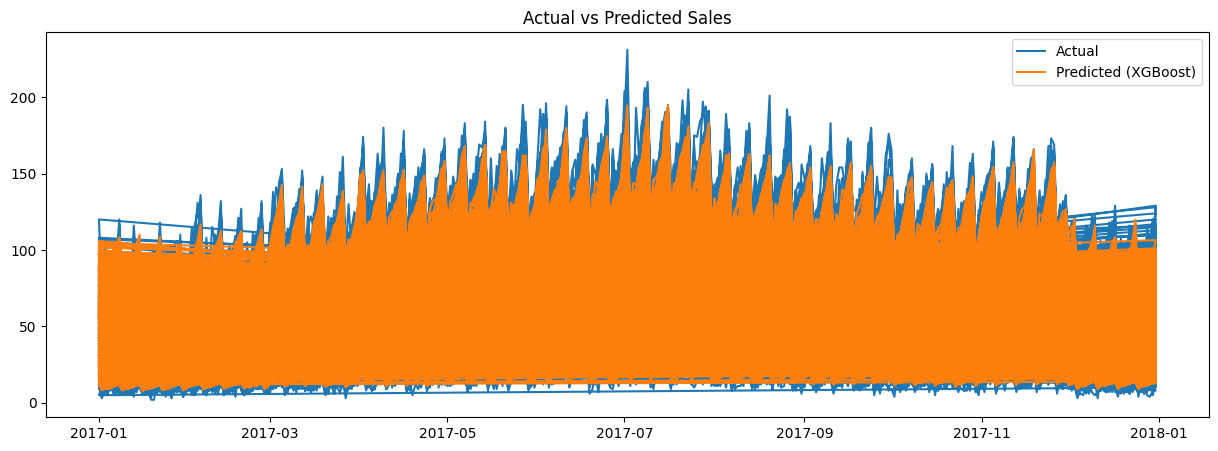

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(valid_df['date'], y_valid.values, label="Actual")
plt.plot(valid_df['date'], pred_xgb, label="Predicted (XGBoost)")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()


In [ ]:
# Blue = actual sales in 2017
# Orange = predicted sales
# Closer lines = better model

In [ ]:
best_model = xgb

# Forecasting Future Sales

In [ ]:
test = pd.read_csv("test.csv", parse_dates=["date"])

In [ ]:
test.head()

,id,date,store,item
0,0,01-01-2018,1,1
1,1,02-01-2018,1,1
2,2,03-01-2018,1,1
3,3,04-01-2018,1,1
4,4,05-01-2018,1,1


In [ ]:
# STEP 1: Force date column to string (fix mixed types)
test['date'] = test['date'].astype(str)

# STEP 2: Convert safely to datetime
test['date'] = pd.to_datetime(test['date'], errors='coerce', format='mixed')

# STEP 3: Extract datetime features safely
test['year'] = test['date'].dt.year
test['month'] = test['date'].dt.month
test['day'] = test['date'].dt.day

# Fix ISO week
week_series = test['date'].dt.isocalendar().week
test['week'] = week_series.astype(int)

# Fix day of week
test['dayofweek'] = test['date'].dt.dayofweek

In [ ]:
# Models expect the same columns they saw during training
# No extra columns
# No missing columns

In [ ]:
# Your model uses:

# lag_1
# lag_7
# lag_30
# rolling_7
# rolling_30

# But test.csv has no sales column, so we cannot directly calculate these.

In [ ]:
# Concatenate training and test data together
# Sort everything by store, item, date
# Compute lag and rolling features across the entire timeline
# Separate them again

In [ ]:
full = pd.concat([train, test], sort=False)
full = full.sort_values(['store','item','date'])

In [ ]:
# This works because:

# Lags for 2018 depend on final dates of 2017
# Rolling averages for Jan 1, 2018 depend on December 2017
# This method avoids leakage

In [ ]:
full['lag_1'] = full.groupby(['store','item'])['sales'].shift(1)
full['lag_7'] = full.groupby(['store','item'])['sales'].shift(7)
full['lag_30'] = full.groupby(['store','item'])['sales'].shift(30)

In [ ]:
full['rolling_7'] = (
    full.groupby(['store','item'])['sales']
    .shift(1)
    .rolling(7)
    .mean()
)

full['rolling_30'] = (
    full.groupby(['store','item'])['sales']
    .shift(1)
    .rolling(30)
    .mean()
)

In [ ]:
test_fe = full[full['sales'].isna()]     # test rows have no sales

# Now test_fe contains:
# all engineered features
# ready for prediction

In [ ]:
test_fe

,date,store,item,sales,dayofweek,month,id,year,day,week,lag_1,lag_7,lag_30,rolling_7,rolling_30
0,2018-01-01,1,1,NaN,0,1,0.0,2018.0,1.0,1.0,23.0,13.0,16.0,18.142857,17.133333
31,2018-01-02,1,1,NaN,1,1,31.0,2018.0,2.0,1.0,NaN,16.0,31.0,NaN,NaN
59,2018-01-03,1,1,NaN,2,1,59.0,2018.0,3.0,1.0,NaN,14.0,7.0,NaN,NaN
12,2018-01-13,1,1,NaN,5,1,12.0,2018.0,13.0,2.0,NaN,19.0,20.0,NaN,NaN
13,2018-01-14,1,1,NaN,6,1,13.0,2018.0,14.0,2.0,NaN,15.0,17.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44951,2018-11-02,10,50,NaN,4,11,44951.0,2018.0,2.0,44.0,NaN,NaN,NaN,NaN,NaN
44979,2018-11-03,10,50,NaN,5,11,44979.0,2018.0,3.0,44.0,NaN,NaN,NaN,NaN,NaN
44921,2018-12-01,10,50,NaN,5,12,44921.0,2018.0,1.0,48.0,NaN,NaN,NaN,NaN,NaN
44952,2018-12-02,10,50,NaN,6,12,44952.0,2018.0,2.0,48.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
test_predictions = best_model.predict(test_fe[features])

# These predictions correspond to the rows in test.csv.

In [ ]:
submission = pd.DataFrame({
    'id': test_fe['id'],
    'sales': test_predictions
})

In [ ]:
submission.to_csv("submission.csv", index=False)

In [ ]:
print("Linear Regression RMSE:", rmse_lr)
print("Random Forest RMSE:", rmse_rf)
print("XGBoost RMSE:", rmse_xgb)

Linear Regression RMSE: 9.240589722310332
Random Forest RMSE: 8.179509575017821
XGBoost RMSE: 7.915868163411868


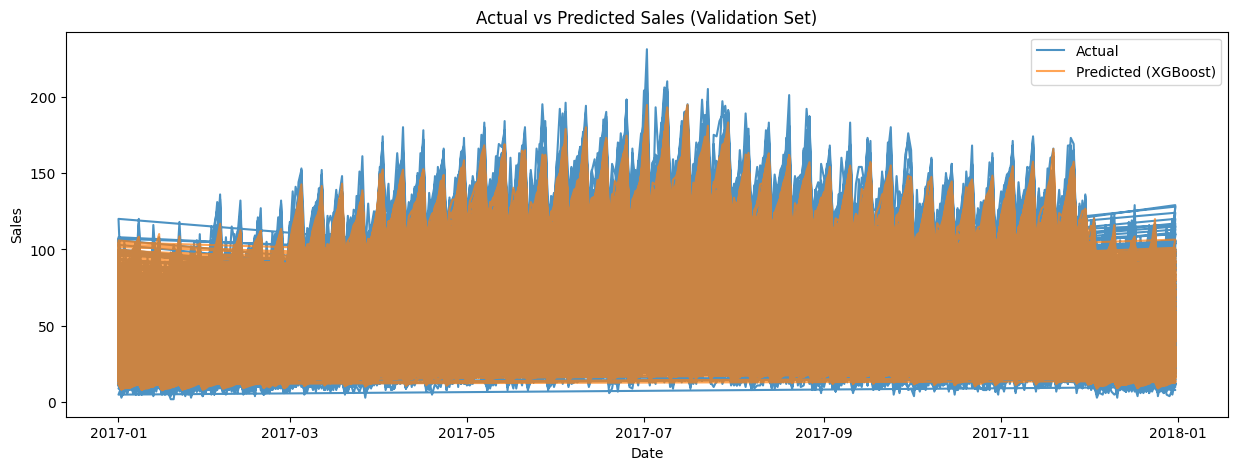

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(valid_df['date'], y_valid.values, label="Actual", alpha=0.8)
plt.plot(valid_df['date'], pred_xgb, label="Predicted (XGBoost)", alpha=0.7)
plt.title("Actual vs Predicted Sales (Validation Set)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

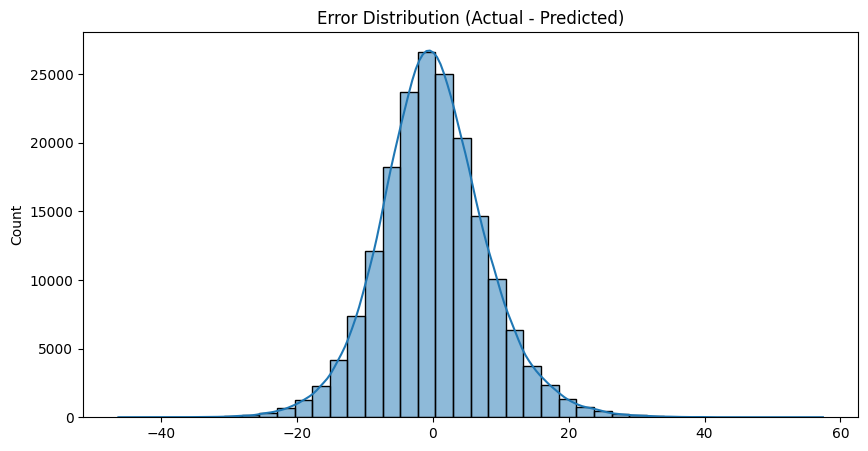

In [ ]:
errors = y_valid.values - pred_xgb

plt.figure(figsize=(10,5))
sns.histplot(errors, bins=40, kde=True)
plt.title("Error Distribution (Actual - Predicted)")
plt.show()

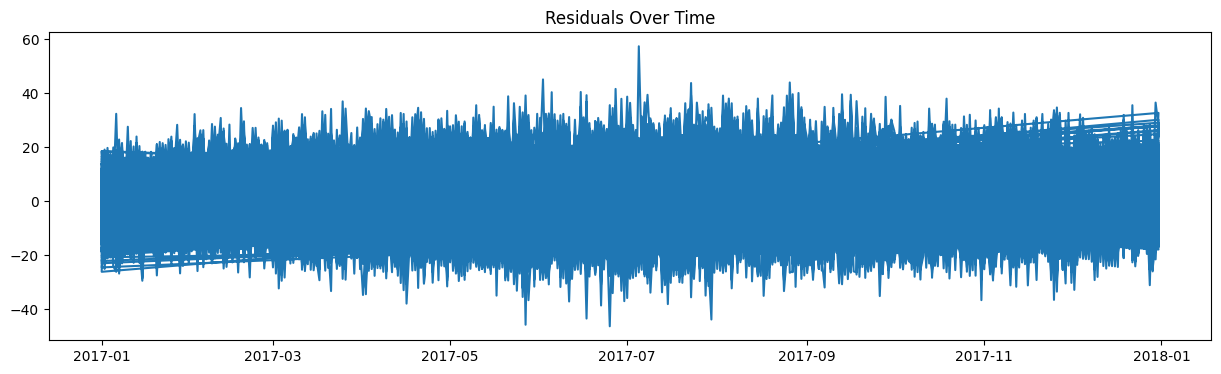

In [ ]:
plt.figure(figsize=(15,4))
plt.plot(valid_df['date'], errors)
plt.title("Residuals Over Time")
plt.show()

In [ ]:
import pandas as pd

importance_df = pd.DataFrame({
    'feature': features,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_df

,feature,importance
10,rolling_7,0.489713
8,lag_7,0.236076
11,rolling_30,0.149440
6,dayofweek,0.084391
7,lag_1,0.014636
3,month,0.011535
5,week,0.005586
4,day,0.003939
9,lag_30,0.002052
2,year,0.000982


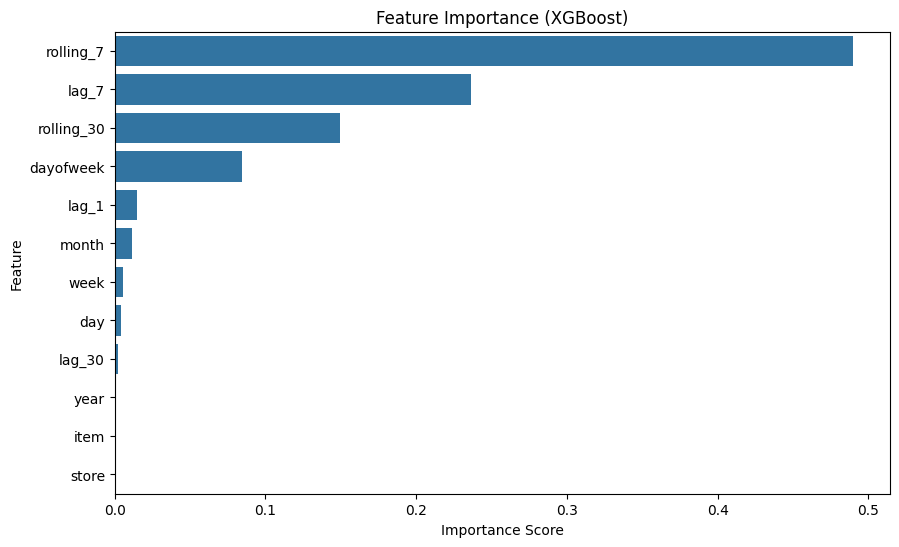

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [ ]:
test_fe[features].head()

,store,item,year,month,day,week,dayofweek,lag_1,lag_7,lag_30,rolling_7,rolling_30
0,1,1,2018,1,1.0,1.0,0,23.0,13.0,16.0,18.142857,17.133333
31,1,1,2018,1,2.0,1.0,1,NaN,16.0,31.0,NaN,NaN
59,1,1,2018,1,3.0,1.0,2,NaN,14.0,7.0,NaN,NaN
12,1,1,2018,1,13.0,2.0,5,NaN,19.0,20.0,NaN,NaN
13,1,1,2018,1,14.0,2.0,6,NaN,15.0,17.0,NaN,NaN


In [ ]:
final_predictions = best_model.predict(test_fe[features])

In [ ]:
submission = pd.DataFrame({
    'id': test_fe['id'],
    'sales': final_predictions
})

In [ ]:
submission.to_csv("final_submission.csv", index=False)

In [ ]:
submission.shape

(45000, 2)

In [ ]:
submission.isna().sum()


id       0
sales    0
dtype: int64

In [ ]:
submission.head()

,id,sales
0,0.0,13.462749
31,31.0,110.661995
59,59.0,108.137566
12,12.0,117.313599
13,13.0,120.198662


In [ ]:
submission.tail()

,id,sales
44951,44951.0,139.055862
44979,44979.0,146.324615
44921,44921.0,128.328064
44952,44952.0,132.471481
44980,44980.0,95.300804


In [ ]:
import joblib

joblib.dump(best_model, "forecasting_model.pkl")

['forecasting_model.pkl']

In [ ]:
# best_model